# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import sklearn

## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [15]:
df= pd.read_csv("c:\\Users\\mhmmd\\Downloads\\Advertising (1).csv")
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Step 2.a Assign variables `X` to the features and `y` to the target

In [21]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

### Step 2.b print the type of each

In [22]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [23]:
print("The target is Numerical and the task is Regression.")

The target is Numerical and the task is Regression.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [24]:
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Number of samples: 200
Number of features: 3


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [ ]:
summary = X.describe()
print(summary)
print("\nMedian values:")
print(X.median())

               TV       radio   newspaper
count  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000
std     85.854236   14.846809   21.778621
min      0.700000    0.000000    0.300000
25%     74.375000    9.975000   12.750000
50%    149.750000   22.900000   25.750000
75%    218.825000   36.525000   45.100000
max    296.400000   49.600000  114.000000

Median values:
TV           149.75
radio         22.90
newspaper     25.75
dtype: float64


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [26]:
ranges = X.max() - X.min()
print("Range for each feature:")
print(ranges)

print(f"\nThe largest difference is in 'TV' with a range of {ranges['TV']:.2f}")

Range for each feature:
TV           295.7
radio         49.6
newspaper    113.7
dtype: float64

The largest difference is in 'TV' with a range of 295.70


### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

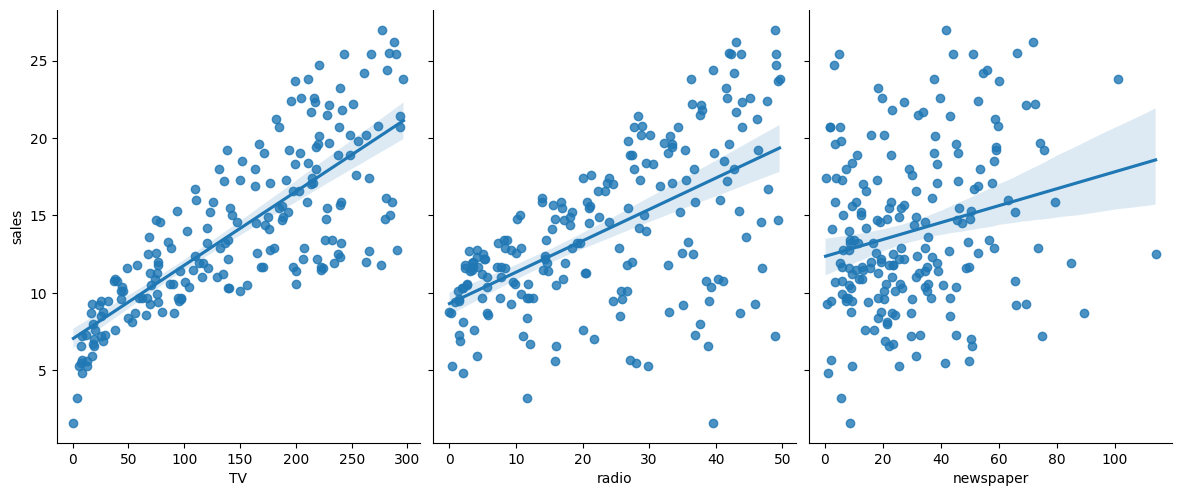

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, x_vars=['TV', 'radio', 'newspaper'], y_vars='sales', height=5, aspect=0.8, kind='reg')
plt.show()

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

In [ ]:
x=TV and y=Sales: (Strong Increasing/Positive relationship).
x=Radio and y=Sales: (Weak Increasing/Positive relationship).
x=Newspaper and y=Sales: (Weak Decreasing/Negative relationship).             

### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# (Pipeline)
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  
    ('scaler', StandardScaler()),                
    ('regressor', LinearRegression())       
])

print("Pipeline defined successfully with Imputer, Scaler, and LinearRegression.")


Pipeline defined successfully with Imputer, Scaler, and LinearRegression.


### Step 8. Split the dataset into train and test sets

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 160
Test set size: 40


### Step 9.a Fit the pipeline on the training set

In [36]:
pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")

Pipeline trained successfully!


### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [37]:
regressor = pipeline.named_steps['regressor']

coeffs = regressor.coef_
bias = regressor.intercept_

print(f"Coefficients (TV, Radio, Newspaper): {coeffs}")
print(f"Bias term (Intercept): {bias}")

Coefficients (TV, Radio, Newspaper): [3.76419618 2.79230665 0.05597551]
Bias term (Intercept): 14.100000000000001


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [38]:
tv_effect = coeffs[0]
print(f"Spending $1,000 more on TV increases sales by: {tv_effect:.4f} units")

Spending $1,000 more on TV increases sales by: 3.7642 units


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [39]:
radio_coeff = coeffs[1]
newspaper_coeff = coeffs[2]

difference = (radio_coeff - newspaper_coeff) * 5
print(f"The difference in sales would be: {difference:.4f} units")

The difference in sales would be: 13.6817 units


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [40]:
sales_at_zero = regressor.intercept_

print(f"If advertising budget is $0, the estimated Sales are: {sales_at_zero:.4f} thousand units")

If advertising budget is $0, the estimated Sales are: 14.1000 thousand units


### Step 10. Evaluate the pipeline on the test set

In [42]:
test_score = pipeline.score(X_test, y_test)

print(f"Pipeline R^2 Score on test set: {test_score:.4f}")

Pipeline R^2 Score on test set: 0.8994


### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?

In [43]:
from sklearn.linear_model import LinearRegression

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

simple_score = simple_model.score(X_test, y_test)

print(f"Simple Model Score: {simple_score:.4f}")
print(f"Pipeline Model Score: {test_score:.4f}")

if test_score > simple_score:
    print("The Pipeline model is better.")
elif simple_score > test_score:
    print("The Simple model is better.")
else:
    print("Both models performed equally.")

Simple Model Score: 0.8994
Pipeline Model Score: 0.8994
The Simple model is better.
